# Repelling and attracting LCS as strain tensor lines

The FTLE map (see `cabo_verde_ftle`) shows *where* the flow stretches, but not
the material curves themselves. Haller (2015, §5.1 / Table 1) constructs those
curves directly from the Cauchy–Green strain tensor
$C = (\nabla F)^\top \nabla F$, whose eigenpairs satisfy
$C\,\xi_i = \lambda_i\,\xi_i$ with $0 < \lambda_1 \le \lambda_2$ and
$\xi_1 \perp \xi_2$. A **repelling** LCS is a *shrink line* — a curve tangent
to $\xi_1$, i.e. orthogonal to the strong-stretch direction $\xi_2$ that the
FTLE ridge marks. It solves the ODE $\dot r = \xi_1(r)$.

Attracting LCS come from the forward–backward duality (Haller & Sapsis 2011):
an **attracting** LCS is just a repelling LCS of the *backward* flow. So we run
the flow both ways from the same initial grid and, in each, integrate the
$\xi_1$ shrink lines:

- **repelling** LCS = shrink lines of the **forward** $C$;
- **attracting** LCS = shrink lines of the **backward** $C$.

We anchor the analysis at the middle of the bundled window ($t_0$ =
2025-08-06, $T = \pm 5$ d) so both runs stay inside the data. It reads the
bundled current subset, so it runs offline — no CMEMS credentials. Run with
`pixi run -e examples jupytext --sync --execute examples/cabo_verde_lcs.py`.

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from parcels import FieldSet, ParticleSet, Particle, StatusCode
from parcels.kernels import AdvectionRK4
from parcels.convert import copernicusmarine_to_sgrid

from lcs_parcels import NeighborSeed

/var/folders/w1/m9mm9h9167z_gcfzfffr0rgsh6j6kj/T/ipykernel_8874/1290272160.py:5: UserWarning: This is an alpha version of Parcels v4. The API is not stable and may change without deprecation warnings.
  from parcels import FieldSet, ParticleSet, Particle, StatusCode


## Currents

The same CMEMS hourly surface velocity as `cabo_verde_ftle`, saved to a file
so the notebook is self-contained. `copernicusmarine_to_sgrid` +
`from_sgrid_conventions` wrap it as a spherical `FieldSet`.

In [2]:
currents = xr.open_dataset("data/cabo_verde_currents_hourly.nc")
sgrid = copernicusmarine_to_sgrid(fields={"U": currents["uo"], "V": currents["vo"]})
fieldset = FieldSet.from_sgrid_conventions(sgrid, mesh="spherical")
z_surface = float(currents["depth"].values[0])

## Seed and advect both ways

A rectilinear `NeighborSeed` over the release box emits one particle per grid
point. The recovery kernel turns lost particles into `NaN` in place so losses
propagate. We advect the same grid forward and backward for $|T|$ and ingest
each into a `FlowMap`.

In [3]:
t0 = np.datetime64("2025-08-06")
T = np.timedelta64(5, "D")
resolution_deg = 1 / 25
seed_lon, seed_lat = (-27.0, -21.0), (13.5, 18.5)

lon_axis = np.arange(seed_lon[0], seed_lon[1] + 1e-9, resolution_deg)
lat_axis = np.arange(seed_lat[0], seed_lat[1] + 1e-9, resolution_deg)
seed = NeighborSeed.from_axes(lon_axis, lat_axis)

In [4]:
def set_lost_to_nan(particles, fieldset):
    lost = particles.state >= StatusCode.Error
    particles.x = np.where(lost, np.nan, particles.x)
    particles.y = np.where(lost, np.nan, particles.y)
    particles.state = np.where(lost, StatusCode.EndofLoop, particles.state)


def advect(signed_T):
    """Advect the seed grid over the signed window; return the FlowMap."""
    lon, lat = (np.asarray(a, dtype=float) for a in seed.to_parcels_pset())
    pset = ParticleSet(
        fieldset, pclass=Particle,
        x=lon, y=lat, z=np.full(lon.size, z_surface), t=np.full(lon.size, t0),
    )
    dt = np.timedelta64(1, "h") if signed_T > np.timedelta64(0) else np.timedelta64(-1, "h")
    pset.execute(
        [AdvectionRK4, set_lost_to_nan],
        dt=dt, runtime=abs(signed_T), verbose_progress=False,
    )
    return seed.pset_to_flowmap(
        np.asarray(pset.x, dtype=float), np.asarray(pset.y, dtype=float),
        t0=t0, t1=t0 + signed_T,
    )


forward = advect(+T)
backward = advect(-T)

## FTLE

The forward FTLE (from $\lambda_2$ of the forward $C$) is the deformation
backdrop and marks where repelling LCS live; the backward FTLE does the same
for attracting LCS. We start each family from the local maxima of its own FTLE.

In [5]:
def ftle_per_day(flowmap):
    # drop the scalar `eig` coord left by ftle()'s lambda_max pick.
    return (flowmap.ftle() * 86400.0).rename("FTLE").drop_vars("eig")


ftle_forward = ftle_per_day(forward)
ftle_backward = ftle_per_day(backward)

## Tracing a tensor line

A shrink line is a trajectory of $\dot r = \xi_1(r)$. Three wrinkles make it
more than a plain ODE solve:

- **No global orientation.** $\xi_1$ and $-\xi_1$ are both eigenvectors, so at
  each step we flip the sign to keep heading the same way.
- **Interpolating a tensor, not a vector.** We bilinearly interpolate the four
  smooth components of $C$ and re-diagonalise at the point — this stays smooth
  through the near-degenerate spots where interpolating $\xi_1$ directly would
  flip.
- **Stop where the LCS stops being one.** We halt a line where the strain is no
  longer clearly hyperbolic, $\lambda_2 < \lambda_{\max}^{\min}$ (default 1.1):
  this both drops the non-repelling stretch and avoids the degenerate
  $\lambda_1 \approx \lambda_2$ region where $\xi_1$ is ill-defined.

`line_tracer` closes over one $C$ field and returns a function that marches all
seeds at once (midpoint step in arc length), both directions from each seed.
The tensor grid is plain NumPy — the tight inner loop is the one place we drop
out of xarray.

In [6]:
def line_tracer(cauchy_green, lambda_max_min=1.1, ds_m=3_000.0, n_steps=250):
    C_grid = cauchy_green.transpose("i", "j", "row", "col").values
    dlon = lon_axis[1] - lon_axis[0]
    dlat = lat_axis[1] - lat_axis[0]
    R = 6_371_000.0  # earth radius (m), matching lcs_parcels' metres frame

    def interp_C(lon, lat):
        """Bilinear-interpolate C at points (lon, lat); NaN outside the grid."""
        gx = (lon - lon_axis[0]) / dlon
        gy = (lat - lat_axis[0]) / dlat
        inside = (gx >= 0) & (gx <= len(lon_axis) - 1) & (gy >= 0) & (gy <= len(lat_axis) - 1)
        # `inside` is already False at NaN points; zero them so the int cast is quiet.
        i0 = np.clip(np.floor(np.where(inside, gx, 0)), 0, len(lon_axis) - 2).astype(int)
        j0 = np.clip(np.floor(np.where(inside, gy, 0)), 0, len(lat_axis) - 2).astype(int)
        fx = (gx - i0)[:, None, None]
        fy = (gy - j0)[:, None, None]
        C = (
            C_grid[i0, j0] * (1 - fx) * (1 - fy)
            + C_grid[i0 + 1, j0] * fx * (1 - fy)
            + C_grid[i0, j0 + 1] * (1 - fx) * fy
            + C_grid[i0 + 1, j0 + 1] * fx * fy
        )
        C[~inside] = np.nan
        return C

    def xi1(pos, heading):
        """Unit xi_1 at pos, oriented to `heading`; NaN where the line should stop."""
        C = interp_C(pos[:, 0], pos[:, 1])
        bad = ~np.isfinite(C).all(axis=(1, 2))
        lam, vecs = np.linalg.eigh(np.where(bad[:, None, None], np.eye(2), C))
        bad = bad | (lam[:, 1] < lambda_max_min)   # not hyperbolic / near-degenerate
        v = vecs[:, :, 0]
        v[np.sum(v * heading, axis=1) < 0] *= -1
        v[bad] = np.nan
        return v

    def step_degrees(pos, v):
        m_per_deg_lat = R * np.pi / 180
        m_per_deg_lon = m_per_deg_lat * np.cos(np.radians(pos[:, 1]))
        return pos + np.column_stack([v[:, 0] / m_per_deg_lon, v[:, 1] / m_per_deg_lat]) * ds_m

    def half_line(seeds, sign):
        pos = seeds.astype(float)
        heading = sign * xi1(pos, np.ones_like(pos))   # pick the initial branch
        track = [pos.copy()]
        for _ in range(n_steps):
            v1 = xi1(pos, heading)
            v2 = xi1(step_degrees(pos, 0.5 * v1), v1)
            pos = step_degrees(pos, v2)
            heading = v2
            track.append(pos.copy())
        return np.stack(track)

    def tensor_lines(seeds):
        both = np.concatenate([half_line(seeds, -1)[::-1], half_line(seeds, +1)[1:]])
        return [both[:, s] for s in range(seeds.shape[0])]

    return tensor_lines

## Where to start the lines

We seed each family at the *local* maxima of its FTLE (the ridge tops) above
the 90th percentile, comparing each point to a 7×7 neighbourhood so the seeds
are well separated and the lines don't bundle.

In [7]:
lon0 = forward.ds["lon_0"].transpose("i", "j").values
lat0 = forward.ds["lat_0"].transpose("i", "j").values


def ridge_seeds(ftle, window=7, quantile=0.90):
    peak = ftle.rolling(i=window, j=window, center=True, min_periods=1).max()
    is_peak = (ftle >= peak) & (ftle >= ftle.quantile(quantile))
    mask = is_peak.transpose("i", "j").values
    return np.column_stack([lon0[mask], lat0[mask]])


repelling = line_tracer(forward.cauchy_green())(ridge_seeds(ftle_forward))
attracting = line_tracer(backward.cauchy_green())(ridge_seeds(ftle_backward))
print(f"{len(repelling)} repelling, {len(attracting)} attracting lines")

54 repelling, 51 attracting lines


## LCS over the FTLE

(13.5, 18.5)

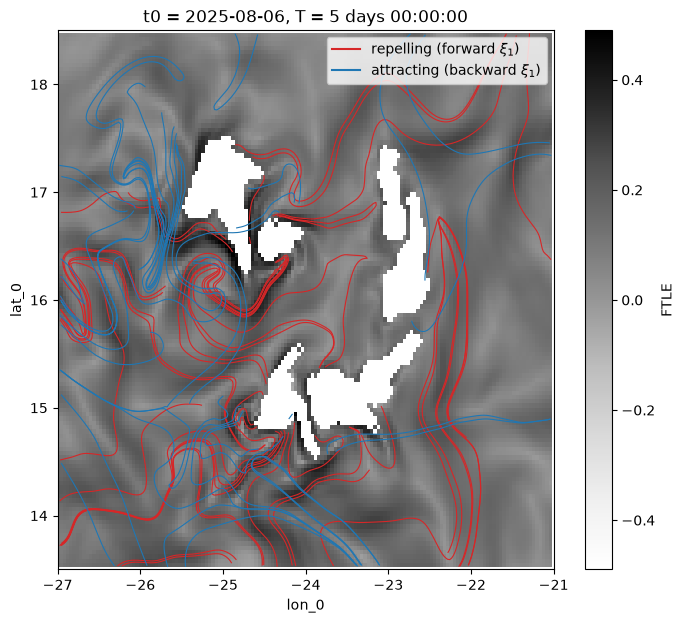

In [8]:
fig, ax = plt.subplots(figsize=(8, 7))
ftle_forward.plot.pcolormesh(x="lon_0", y="lat_0", ax=ax, cmap="Greys", add_colorbar=True)
for line in repelling:
    ax.plot(line[:, 0], line[:, 1], color="tab:red", lw=0.8)
for line in attracting:
    ax.plot(line[:, 0], line[:, 1], color="tab:blue", lw=0.8)
ax.plot([], [], color="tab:red", label="repelling (forward $\\xi_1$)")
ax.plot([], [], color="tab:blue", label="attracting (backward $\\xi_1$)")
ax.legend(loc="upper right")
ax.set_xlim(seed_lon)
ax.set_ylim(seed_lat)